In [1]:
from scipy.stats import gamma
import numpy as np
import matplotlib.pyplot as plt
from src.transform.transform import Transform


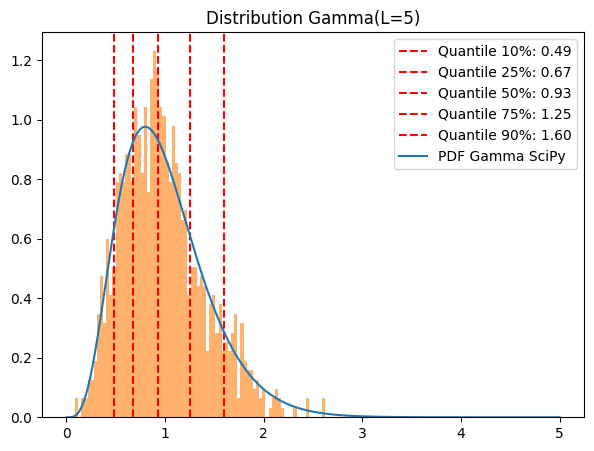

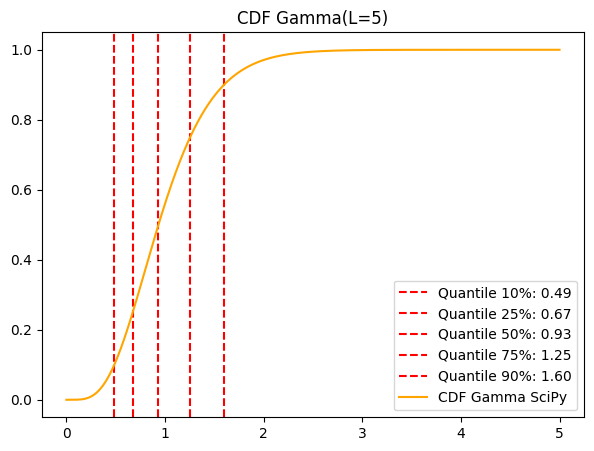

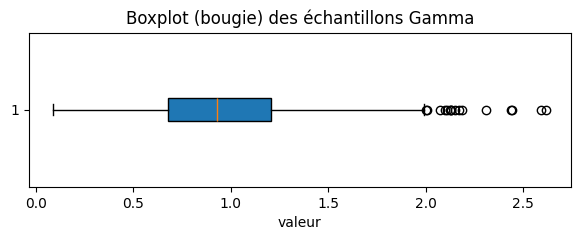

Moyenne théorique: 1.0
Variance théorique: 0.2


: 

In [ ]:

L = 5  # nombre de looks

shape = L
scale = 1.0 / L

x = np.linspace(0.001, 5, 50000)

# add quantiles lines, 25%, 50%, 75%
quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]


# PDF
pdf = gamma.pdf(x, a=shape, scale=scale)

# échantillons
samples = gamma.rvs(a=shape, scale=scale, size=1000)

# === FIGURE 1 : PDF + HISTOGRAMME ===
plt.figure(figsize=(7,5))
for q in quantiles:
	q_value = gamma.ppf(q, a=shape, scale=scale)
	plt.axvline(q_value, color='red', linestyle='--', label=f'Quantile {q*100:.0f}%: {q_value:.2f}')
plt.plot(x, pdf, label="PDF Gamma SciPy")
plt.hist(samples, bins=80, density=True, alpha=0.6)
plt.legend()
plt.title(f"Distribution Gamma(L={L})")
plt.show()

# === FIGURE 2 : Integral Cumulative Distribution Function (CDF) ===
cdf = gamma.cdf(x, a=shape, scale=scale)
plt.figure(figsize=(7,5))



for q in quantiles:
	q_value = gamma.ppf(q, a=shape, scale=scale)
	plt.axvline(q_value, color='red', linestyle='--', label=f'Quantile {q*100:.0f}%: {q_value:.2f}')
plt.plot(x, cdf, label="CDF Gamma SciPy", color='orange')
plt.title(f"CDF Gamma(L={L})")
plt.legend()
plt.show()

# === FIGURE 3 : BOX PLOT (BOUGIE) ===
plt.figure(figsize=(7,2))
plt.boxplot(samples, vert=False, patch_artist=True)
plt.title("Boxplot (bougie) des échantillons Gamma")
plt.xlabel("valeur")
plt.show()

print("Moyenne théorique:", gamma.mean(a=L, scale=1/L))
print("Variance théorique:", gamma.var(a=L, scale=1/L))


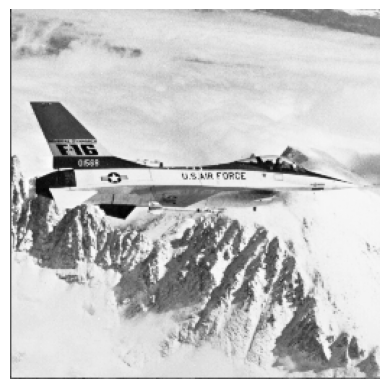

In [11]:
path_to_img = Transform.get_images_list()[0]

#plot the image with cv2.imshow
import cv2

img = cv2.imread(path_to_img, cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

In [12]:
# img to numpy array between 0 and 1
img_numpy = Transform.load_image(path_to_img)
print("img_numpy shape:", img_numpy.shape)
print("min:", img_numpy.min())
print("max:", img_numpy.max())
print("mean:", img_numpy.mean())
print("std:", img_numpy.std())

# generate gamma noise
noise = np.random.gamma(L, 1.0 / L, img_numpy.shape).astype(np.float32)
print("noise shape:", noise.shape)
print("noise min:", noise.min())
print("noise max:", noise.max())
print("noise mean:", noise.mean())
print("noise std:", noise.std())

noised_img = img_numpy * noise
print("noised_img shape:", noised_img.shape)
print("noised_img min:", noised_img.min())
print("noised_img max:", noised_img.max())
print("noised_img mean:", noised_img.mean())
print("noised_img std:", noised_img.std())

img_numpy shape: (256, 256)
min: 0.0627451
max: 0.9019608
mean: 0.69896454
std: 0.18350331
noise shape: (256, 256)
noise min: 0.51512676
noise max: 1.6941208
noise mean: 1.0004271
noise std: 0.14176628
noised_img shape: (256, 256)
noised_img min: 0.050715156
noised_img max: 1.3960919
noised_img mean: 0.6992004
noised_img std: 0.21016006


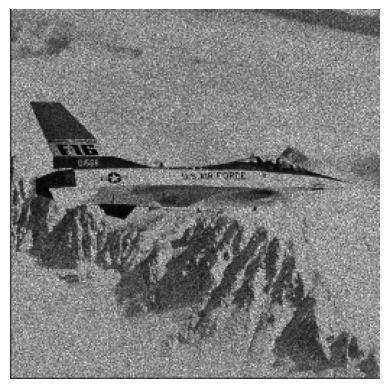

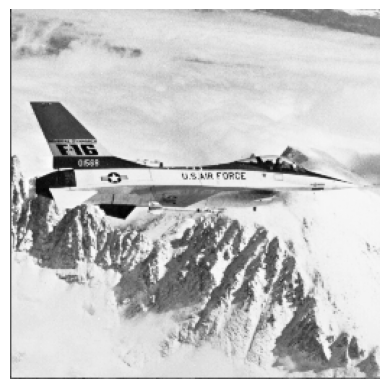

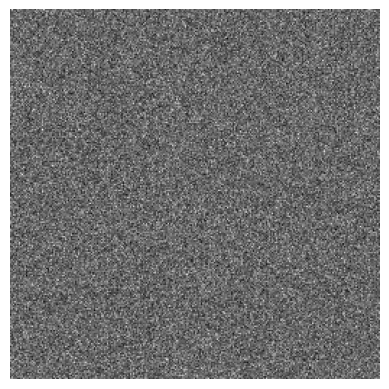

In [13]:
# plot noised_img, before we normalize to 0-255
noised_img_normalized = cv2.normalize(noised_img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
plt.imshow(noised_img_normalized, cmap='gray')
plt.axis('off')
plt.show()

img = cv2.imread(path_to_img, cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

# plot the noise
plt.imshow(noise, cmap='gray')
plt.axis('off')
plt.show()